In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# In VSCode, right click on train.csv --> copy path, paste here
path = "/Users/matteogiardina/Desktop/BEMACS 2/2nd semester/ML Project/Data/train.csv"
df = pd.read_csv(path)
df = df.drop(columns=["Unnamed: 0"])
print(len(df))

110930


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110930 entries, 0 to 110929
Data columns (total 40 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unique Key                            110930 non-null  int64  
 1   Created Date                          110930 non-null  str    
 2   Closed Date                           91738 non-null   str    
 3   Agency                                110930 non-null  str    
 4   Agency Name                           110930 non-null  str    
 5   Problem (formerly Complaint Type)     110930 non-null  str    
 6   Problem Detail (formerly Descriptor)  109098 non-null  str    
 7   Additional Details                    41038 non-null   str    
 8   Location Type                         93679 non-null   str    
 9   Incident Zip                          109894 non-null  float64
 10  Incident Address                      105945 non-null  str    
 11  Street Name

In [5]:
df["Agency"].value_counts()

Agency
NYPD          49247
HPD           22690
DOT           10523
DSNY           9354
DEP            5660
DOB            3624
DPR            2855
DOHMH          2472
DHS            1644
TLC            1204
DCWP            637
EDC             554
NYC311-PRD      323
OOS             132
OTI              11
Name: count, dtype: int64

In [6]:
df["Agency Name"].value_counts()

Agency Name
New York City Police Department                       49247
Department of Housing Preservation and Development    22690
Department of Transportation                          10523
Department of Sanitation                               9354
Department of Environmental Protection                 5660
Department of Buildings                                3624
Department of Parks and Recreation                     2855
Department of Health and Mental Hygiene                2472
Department of Homeless Services                        1644
Taxi and Limousine Commission                          1204
Department of Consumer and Worker Protection            637
Economic Development Corporation                        554
HIQA                                                    323
Office of the Sheriff                                   132
Office of Technology and Innovation                      11
Name: count, dtype: int64

In [33]:
num_categories = df["Problem (formerly Complaint Type)"].nunique()

# # Step 1: Get the number of rows for each unique category
# category_counts = df["Problem (formerly Complaint Type)"].value_counts()

# # Step 2: Count how often each frequency occurs and sort them
# frequency_of_frequencies = category_counts.value_counts().sort_index()


# # Create the histogram
# plt.figure(figsize=(10, 5))

# # We use bins=50 to chunk the data. 
# # You might want to zoom in by adding a range, like range=(1, 100) if the long tail is too massive
# plt.hist(category_counts, bins=50, edgecolor='black', range = (1, 100))

# plt.title('How many rows does each category have? (Zoomed in 1 to 100)')
# plt.xlabel('Number of Rows (Frequency of the Category)')
# plt.ylabel('Number of Categories')
# plt.show()

print(df["Problem (formerly Complaint Type)"].value_counts().to_string())

Problem (formerly Complaint Type)
Illegal Parking                            18014
Noise - Residential                        12383
HEAT/HOT WATER                              7756
Street Condition                            6466
Blocked Driveway                            5008
Noise - Street/Sidewalk                     4713
UNSANITARY CONDITION                        3729
Abandoned Vehicle                           2457
PLUMBING                                    2308
Dirty Condition                             2147
Noise                                       2071
Water System                                2013
PAINT/PLASTER                               1933
Noise - Commercial                          1833
DOOR/WINDOW                                 1580
Noise - Vehicle                             1558
Encampment                                  1339
General Construction/Plumbing               1268
Traffic Signal Condition                    1251
Derelict Vehicles                  

In [34]:
def group_problem(text):
    # Convert to uppercase to catch "PLUMBING" and "Plumbing" identically
    text = str(text).upper()
    
    # 1. Noise Complaints
    if 'NOISE' in text: 
        return 'Noise'
        
    # 2. Vehicles and Parking
    elif 'PARKING' in text or 'VEHICLE' in text or 'DRIVEWAY' in text or 'TAXI' in text or 'FOR HIRE' in text: 
        return 'Vehicles & Parking'
        
    # 3. Housing and Indoor Building Issues
    elif 'HEAT' in text or 'PAINT' in text or 'DOOR' in text or 'FLOOR' in text or 'ELECTRIC' in text or 'APPLIANCE' in text or 'ELEVATOR' in text or 'MOLD' in text or 'BOILER' in text: 
        return 'Housing & Buildings'
        
    # 4. Water, Plumbing, and Sewers
    elif 'WATER' in text or 'SEWER' in text or 'PLUMBING' in text or 'LEAK' in text: 
        return 'Water & Plumbing'
        
    # 5. Street and Infrastructure
    elif 'STREET' in text or 'SIDEWALK' in text or 'HIGHWAY' in text or 'TRAFFIC' in text or 'CURB' in text or 'SIGN' in text or 'BRIDGE' in text: 
        return 'Street & Infrastructure'
        
    # 6. Sanitation and Garbage
    elif 'SANITARY' in text or 'DIRTY' in text or 'DUMPING' in text or 'COLLECTION' in text or 'DISPOSAL' in text or 'LITTER' in text or 'SWEEPING' in text: 
        return 'Sanitation & Garbage'
        
    # 7. Trees and Parks
    elif 'TREE' in text or 'PARK' in text or 'WOOD' in text or 'STUMP' in text or 'PLANT' in text: 
        return 'Trees & Parks'
        
    # 8. Animals and Pests
    elif 'ANIMAL' in text or 'DOG' in text or 'RODENT' in text or 'PIGEON' in text or 'BEE' in text: 
        return 'Animals & Pests'
        
    # 9. General / Everything Else
    else: 
        return 'Other'

# Apply the function to create a brand new, clean column
df['Problem_Grouped'] = df['Problem (formerly Complaint Type)'].apply(group_problem)

# Drop the old, messy column
# df = df.drop(columns=['Problem (formerly Complaint Type)'])

# Let's see the new, clean distribution!
print(df['Problem_Grouped'].value_counts())

Problem_Grouped
Vehicles & Parking         27907
Noise                      23413
Housing & Buildings        15327
Other                      12874
Street & Infrastructure    10914
Sanitation & Garbage        9065
Water & Plumbing            8102
Trees & Parks               1810
Animals & Pests             1518
Name: count, dtype: int64


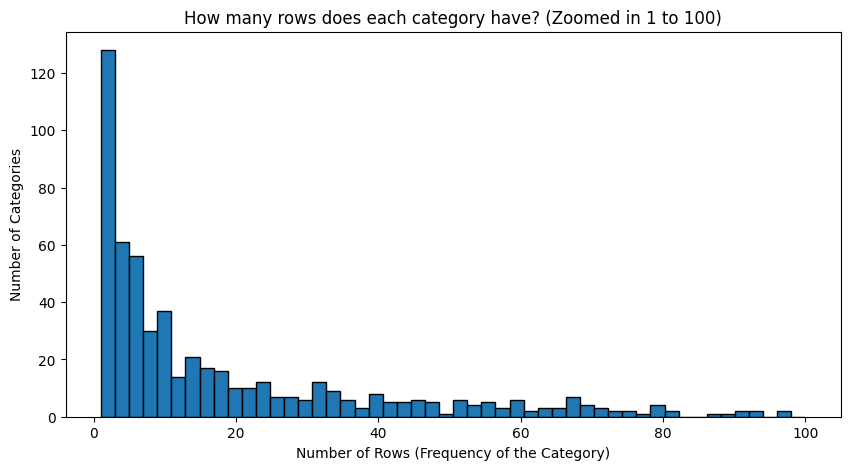

Problem Detail (formerly Descriptor)
Loud Music/Party               11558
ENTIRE BUILDING                 5323
Banging/Pounding                5011
Blocked Hydrant                 4923
Pothole                         4887
                               ...  
General Vendor                     1
Air: Odor, Nail Salon (AD8)        1
Unsanitary Condition               1
Flood Light Lamp Cycling           1
Credit Card Stuck in Meter         1
Name: count, Length: 700, dtype: int64

In [8]:
num_categories = df["Problem Detail (formerly Descriptor)"].nunique()

# Step 1: Get the number of rows for each unique category
category_counts = df["Problem Detail (formerly Descriptor)"].value_counts()

# Step 2: Count how often each frequency occurs and sort them
frequency_of_frequencies = category_counts.value_counts().sort_index()


# Create the histogram
plt.figure(figsize=(10, 5))

# We use bins=50 to chunk the data. 
# You might want to zoom in by adding a range, like range=(1, 100) if the long tail is too massive
plt.hist(category_counts, bins=50, edgecolor='black', range = (1, 100))

plt.title('How many rows does each category have? (Zoomed in 1 to 100)')
plt.xlabel('Number of Rows (Frequency of the Category)')
plt.ylabel('Number of Categories')
plt.show()
 
df["Problem Detail (formerly Descriptor)"].value_counts()

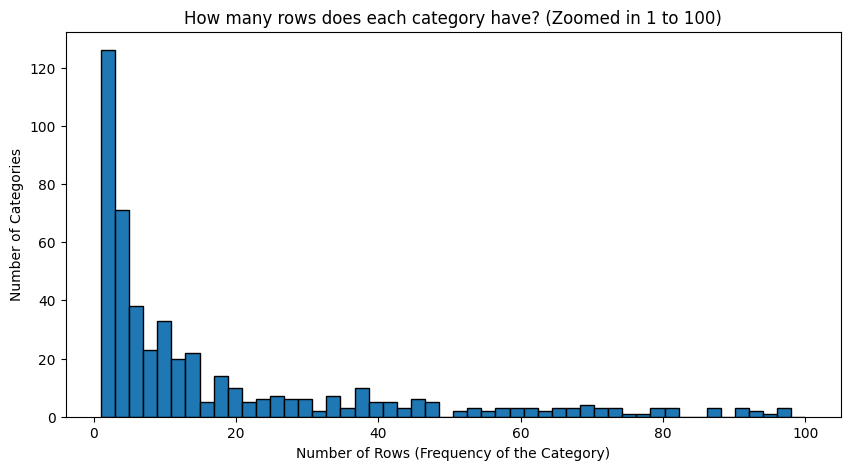

Additional Details
NO HEAT                            4103
NO HEAT AND NO HOT WATER           1921
NO HOT WATER                       1858
BROKEN OR MISSING                  1266
Littering                          1074
                                   ... 
Credit Card Limits Not Posted         1
AD8                                   1
JANITOR/SUPER EMERGENCY CONTACT       1
Combined Pickups                      1
Picnic Table                          1
Name: count, Length: 577, dtype: int64

In [9]:
num_categories = df["Additional Details"].nunique()

# Step 1: Get the number of rows for each unique category
category_counts = df["Additional Details"].value_counts()

# Step 2: Count how often each frequency occurs and sort them
frequency_of_frequencies = category_counts.value_counts().sort_index()


# Create the histogram
plt.figure(figsize=(10, 5))

# We use bins=50 to chunk the data. 
# You might want to zoom in by adding a range, like range=(1, 100) if the long tail is too massive
plt.hist(category_counts, bins=50, edgecolor='black', range = (1, 100))

plt.title('How many rows does each category have? (Zoomed in 1 to 100)')
plt.xlabel('Number of Rows (Frequency of the Category)')
plt.ylabel('Number of Categories')
plt.show()
 
df["Additional Details"].value_counts()

In [39]:
num_categories = df["Location Type"].nunique()

# # Step 1: Get the number of rows for each unique category
# category_counts = df["Location Type"].value_counts()

# # Step 2: Count how often each frequency occurs and sort them
# frequency_of_frequencies = category_counts.value_counts().sort_index()


# # Create the histogram
# plt.figure(figsize=(10, 5))

# # We use bins=50 to chunk the data. 
# # You might want to zoom in by adding a range, like range=(1, 100) if the long tail is too massive
# plt.hist(category_counts, bins=50, edgecolor='black', range = (1, 100))

# plt.title('How many rows does each category have? (Zoomed in 1 to 100)')
# plt.xlabel('Number of Rows (Frequency of the Category)')
# plt.ylabel('Number of Categories')
# plt.show()
 
print(df["Location Type"].value_counts().to_string())

Location Type
Street/Sidewalk                         33807
RESIDENTIAL BUILDING                    22690
Residential Building/House              13500
Street                                   9169
Sidewalk                                 4829
Store/Commercial                         1770
Park                                      887
Club/Bar/Restaurant                       760
Business                                  569
Above Address                             554
Restaurant/Bar/Deli/Bakery                480
3+ Family Apt. Building                   453
Park/Playground                           426
3+ Family Apartment Building              347
Subway                                    294
Highway                                   280
Street/Curbside                           256
Yard                                      248
1-2 Family Dwelling                       231
Residential Building                      219
Taxi                                      201
Mixed Use           

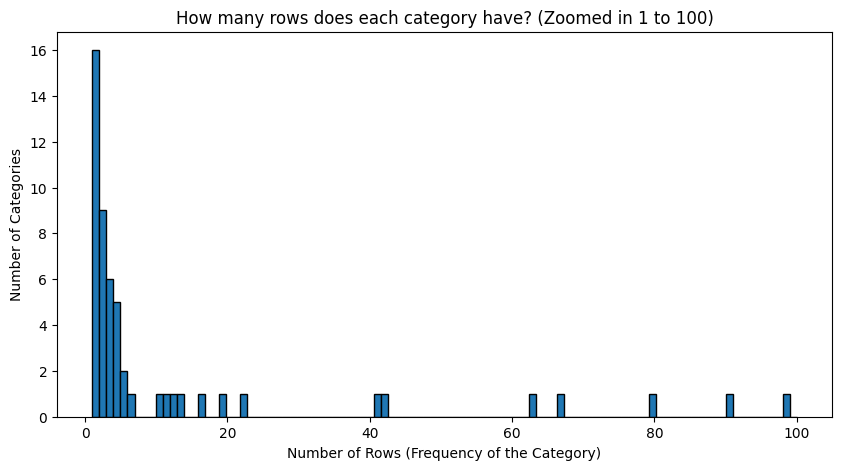

Incident Zip
10466.0    1835
11226.0    1828
10452.0    1520
10457.0    1485
10453.0    1482
           ... 
11371.0       1
10179.0       1
10151.0       1
10111.0       1
10278.0       1
Name: count, Length: 222, dtype: int64


In [41]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Incident Zip"].value_counts()

# Step 2: Count how often each frequency occurs and sort them
frequency_of_frequencies = category_counts.value_counts().sort_index()


# Create the histogram
plt.figure(figsize=(10, 5))

# We use bins=50 to chunk the data. 
# You might want to zoom in by adding a range, like range=(1, 100) if the long tail is too massive
plt.hist(category_counts, bins=100, edgecolor='black', range=(1,100))

plt.title('How many rows does each category have? (Zoomed in 1 to 100)')
plt.xlabel('Number of Rows (Frequency of the Category)')
plt.ylabel('Number of Categories')
plt.show()
 
print(category_counts)

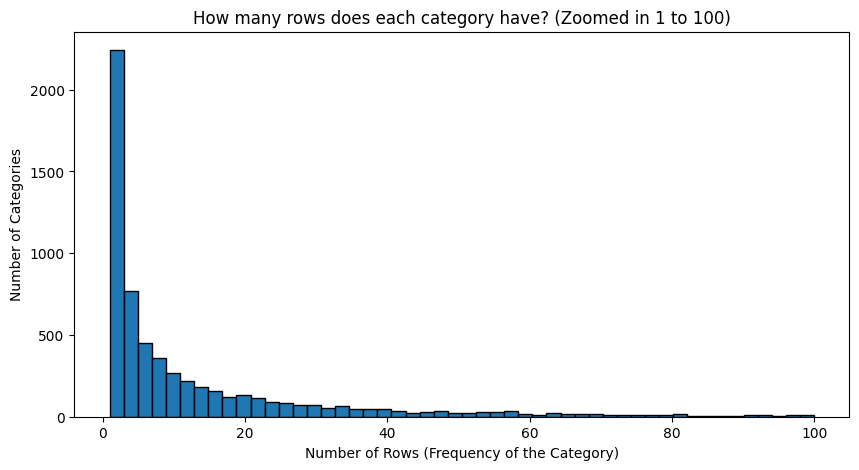

Street Name
BROADWAY               1402
EAST 230 STREET         974
GRAND CONCOURSE         657
5 AVENUE                615
3 AVENUE                530
                       ... 
AZALEA COURT              1
BEACH  102 STREET         1
EDGEWATER STREET          1
LENOX TERRACE PLACE       1
35 ROAD                   1
Name: count, Length: 6210, dtype: int64


In [12]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Street Name"].value_counts()

# Step 2: Count how often each frequency occurs and sort them
frequency_of_frequencies = category_counts.value_counts().sort_index()


# Create the histogram
plt.figure(figsize=(10, 5))

# We use bins=50 to chunk the data. 
# You might want to zoom in by adding a range, like range=(1, 100) if the long tail is too massive
plt.hist(category_counts, bins=50, edgecolor='black', range = (1, 100))

plt.title('How many rows does each category have? (Zoomed in 1 to 100)')
plt.xlabel('Number of Rows (Frequency of the Category)')
plt.ylabel('Number of Categories')
plt.show()
 
print(category_counts)

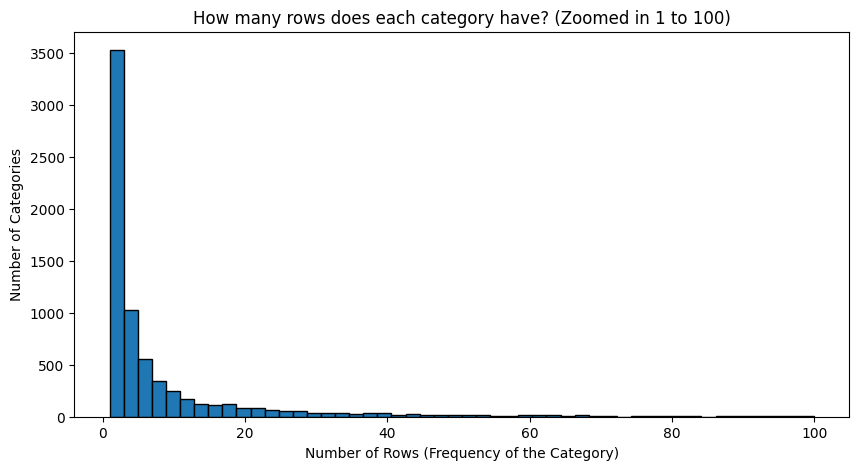

Cross Street 1
CARPENTER AVENUE            1024
BROADWAY                     920
3 AVENUE                     793
5 AVENUE                     762
BEND                         657
                            ... 
E 22 ST                        1
PELHAM PARKWAY WESTBOUND       1
JOHN CAPITANO PLACE            1
HUNTINGTON ST                  1
FAIRCHILD AVENUE               1
Name: count, Length: 7199, dtype: int64


In [13]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Cross Street 1"].value_counts()

# Step 2: Count how often each frequency occurs and sort them
frequency_of_frequencies = category_counts.value_counts().sort_index()


# Create the histogram
plt.figure(figsize=(10, 5))

# We use bins=50 to chunk the data. 
# You might want to zoom in by adding a range, like range=(1, 100) if the long tail is too massive
plt.hist(category_counts, bins=50, edgecolor='black', range = (1, 100))

plt.title('How many rows does each category have? (Zoomed in 1 to 100)')
plt.xlabel('Number of Rows (Frequency of the Category)')
plt.ylabel('Number of Categories')
plt.show()
 
print(category_counts)

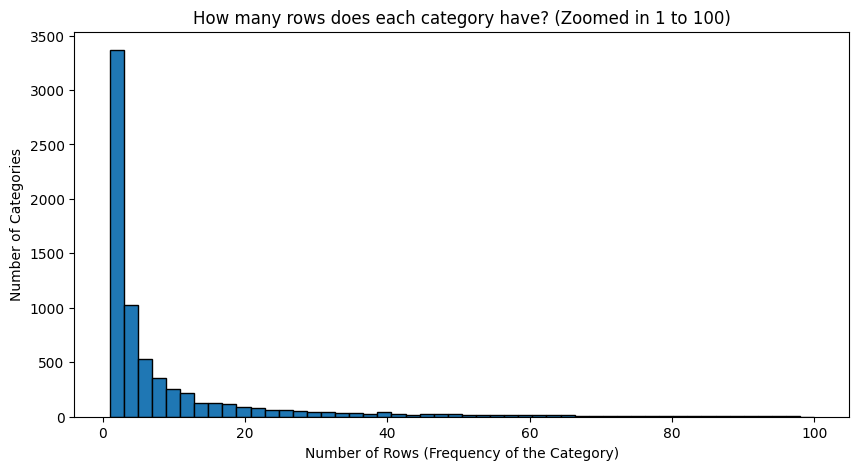

Cross Street 2
BROADWAY          980
LOWERRE PLACE     976
DEAD END          827
2 AVENUE          496
3 AVENUE          476
                 ... 
DULANCEY COURT      1
OCEAN COURT         1
RIDGE ST            1
REVERE AVENUE       1
TAXTER PLACE        1
Name: count, Length: 7077, dtype: int64


In [14]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Cross Street 2"].value_counts()

# Step 2: Count how often each frequency occurs and sort them
frequency_of_frequencies = category_counts.value_counts().sort_index()


# Create the histogram
plt.figure(figsize=(10, 5))

# We use bins=50 to chunk the data. 
# You might want to zoom in by adding a range, like range=(1, 100) if the long tail is too massive
plt.hist(category_counts, bins=50, edgecolor='black', range = (1, 100))

plt.title('How many rows does each category have? (Zoomed in 1 to 100)')
plt.xlabel('Number of Rows (Frequency of the Category)')
plt.ylabel('Number of Categories')
plt.show()
 
print(category_counts)

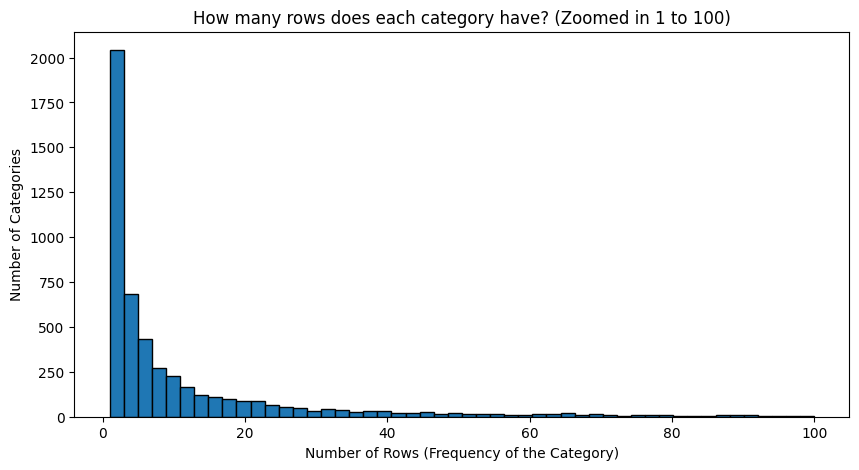

Intersection Street 1
CARPENTER AVENUE            1024
BROADWAY                     937
3 AVENUE                     861
5 AVENUE                     782
AMSTERDAM AVENUE             561
                            ... 
NEPTUNE LANE                   1
DUTCH KILLS STREET             1
PELHAM PARKWAY WESTBOUND       1
BEACH 143 STREET               1
FAIRCHILD AVENUE               1
Name: count, Length: 5119, dtype: int64


In [15]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Intersection Street 1"].value_counts()

# Step 2: Count how often each frequency occurs and sort them
frequency_of_frequencies = category_counts.value_counts().sort_index()


# Create the histogram
plt.figure(figsize=(10, 5))

# We use bins=50 to chunk the data. 
# You might want to zoom in by adding a range, like range=(1, 100) if the long tail is too massive
plt.hist(category_counts, bins=50, edgecolor='black', range = (1, 100))

plt.title('How many rows does each category have? (Zoomed in 1 to 100)')
plt.xlabel('Number of Rows (Frequency of the Category)')
plt.ylabel('Number of Categories')
plt.show()
 
print(category_counts)

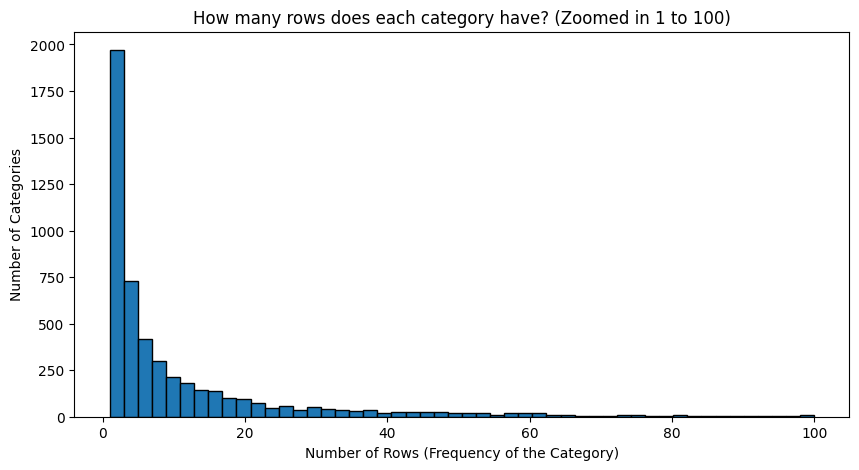

Intersection Street 2
LOWERRE PLACE         976
BROADWAY              909
DEAD END              686
2 AVENUE              489
7 AVENUE              460
                     ... 
COLLEGE POINT BLVD      1
OCEAN COURT             1
QUEENS STREET           1
CEBRA AVENUE            1
TAXTER PLACE            1
Name: count, Length: 5148, dtype: int64


In [16]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Intersection Street 2"].value_counts()

# Step 2: Count how often each frequency occurs and sort them
frequency_of_frequencies = category_counts.value_counts().sort_index()


# Create the histogram
plt.figure(figsize=(10, 5))

# We use bins=50 to chunk the data. 
# You might want to zoom in by adding a range, like range=(1, 100) if the long tail is too massive
plt.hist(category_counts, bins=50, edgecolor='black', range = (1, 100))

plt.title('How many rows does each category have? (Zoomed in 1 to 100)')
plt.xlabel('Number of Rows (Frequency of the Category)')
plt.ylabel('Number of Categories')
plt.show()
 
print(category_counts)

In [17]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Address Type"].value_counts()
 
print(category_counts)

Address Type
ADDRESS         97085
INTERSECTION     8778
BLOCKFACE        3594
PLACE             798
PLACENAME          37
Name: count, dtype: int64


In [18]:
# Step 1: Get the number of rows for each unique category
category_counts = df["City"].value_counts()
 
print(category_counts)

len(category_counts)

City
BROOKLYN               31603
BRONX                  22034
NEW YORK               19725
STATEN ISLAND           4056
QUEENS                  2913
JAMAICA                 2539
ASTORIA                 2207
FLUSHING                1833
MANHATTAN               1294
RIDGEWOOD               1238
LONG ISLAND CITY        1213
CORONA                  1097
FAR ROCKAWAY             903
WOODSIDE                 765
SOUTH RICHMOND HILL      759
JACKSON HEIGHTS          747
SOUTH OZONE PARK         743
ELMHURST                 698
FRESH MEADOWS            656
OZONE PARK               605
MASPETH                  577
REGO PARK                545
EAST ELMHURST            540
QUEENS VILLAGE           520
WOODHAVEN                495
MIDDLE VILLAGE           394
RICHMOND HILL            387
FOREST HILLS             384
BAYSIDE                  378
COLLEGE POINT            355
WHITESTONE               348
HOLLIS                   277
SUNNYSIDE                276
SPRINGFIELD GARDENS      275
SAINT ALB

54

In [19]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Landmark"].value_counts()
 
print(category_counts)

len(category_counts)

Landmark
EAST 230 STREET    974
BROADWAY           938
5 AVENUE           406
50 AVENUE          406
8 AVENUE           402
                  ... 
FLEET COURT          1
GRANT STREET         1
AZALEA COURT         1
MILBURN STREET       1
35 ROAD              1
Name: count, Length: 4636, dtype: int64


4636

In [20]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Facility Type"].value_counts()
 
print(category_counts)

Facility Type
DSNY Garage    363
Name: count, dtype: int64


In [42]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Community Board"].value_counts()

print(category_counts)

Community Board
12 MANHATTAN        3283
12 BRONX            3231
01 QUEENS           3000
07 QUEENS           2848
01 BROOKLYN         2823
                    ... 
28 BRONX              17
95 STATEN ISLAND      13
56 BROOKLYN           12
27 BRONX              10
84 QUEENS              7
Name: count, Length: 77, dtype: int64


In [22]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Borough"].value_counts()
 
print(category_counts)

Borough
BROOKLYN         32989
QUEENS           28148
BRONX            22809
MANHATTAN        22537
STATEN ISLAND     4330
Unspecified        117
Name: count, dtype: int64


In [23]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Council District"].value_counts()
 
print(category_counts)

len(category_counts)

Council District
11.0    3538
16.0    3379
9.0     3228
10.0    3208
14.0    3053
15.0    2977
3.0     2865
40.0    2825
35.0    2820
17.0    2648
33.0    2599
26.0    2532
22.0    2463
1.0     2457
34.0    2440
2.0     2314
30.0    2298
37.0    2271
13.0    2190
28.0    2185
39.0    2165
36.0    2122
8.0     2117
38.0    2097
7.0     1946
42.0    1937
32.0    1920
41.0    1903
6.0     1895
47.0    1866
27.0    1794
12.0    1790
48.0    1764
31.0    1746
4.0     1724
45.0    1702
21.0    1678
29.0    1657
19.0    1633
24.0    1625
25.0    1570
18.0    1567
20.0    1552
49.0    1457
43.0    1446
50.0    1323
51.0    1320
23.0    1298
46.0    1268
44.0    1177
5.0     1076
Name: count, dtype: int64


51

In [24]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Police Precinct"].value_counts()
 
print(category_counts)

len(category_counts)

Police Precinct
Precinct 47     3240
Precinct 114    3040
Precinct 44     2748
Precinct 109    2657
Precinct 75     2637
                ... 
Precinct 69      598
Precinct 17      544
Precinct 100     527
Precinct 26      475
Precinct 22      107
Name: count, Length: 78, dtype: int64


78

In [25]:
# Step 1: Get the number of rows for each unique category
category_counts = df["BBL"].value_counts()
 
print(category_counts)

len(category_counts)

BBL
2.048330e+09    970
4.000320e+09    355
4.006320e+09    309
3.026190e+09    255
3.063150e+09    240
               ... 
1.019220e+09      1
3.052200e+09      1
4.028880e+09      1
4.012700e+09      1
4.040360e+09      1
Name: count, Length: 43815, dtype: int64


43815

In [26]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Open Data Channel Type"].value_counts()
 
print(category_counts)

len(category_counts)

Open Data Channel Type
ONLINE     50202
PHONE      26031
MOBILE     22824
UNKNOWN    11873
Name: count, dtype: int64


4

In [27]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Park Facility Name"].value_counts()
 
print(category_counts)

len(category_counts)

Park Facility Name
Unspecified                              110851
Isham Park                                    4
MacDonald Park                                1
Sarah J.S. Tompkins Garnet Playground         1
Forest Park                                   1
Name: count, dtype: int64


5

In [28]:
# Replace 'Col1' and 'Col2' with your actual column names
num_differences = (df['Borough'] != df['Park Borough']).sum()

print(f"These two columns differ in {num_differences} rows.")

These two columns differ in 0 rows.


In [29]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Vehicle Type"].value_counts()
 
print(category_counts)

len(category_counts)

Vehicle Type
Car            3389
SUV             611
Other           602
Van             413
Truck           322
Car Service      35
Name: count, dtype: int64


6

In [30]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Taxi Company Borough"].value_counts()
 
print(category_counts)

len(category_counts)

Taxi Company Borough
MANHATTAN        21
QUEENS           20
BROOKLYN         12
BRONX            10
STATEN ISLAND     7
Name: count, dtype: int64


5

In [31]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Bridge Highway Name"].value_counts()
 
print(category_counts)

len(category_counts)

Bridge Highway Name
A                                             39
1                                             37
D                                             35
BQE/Gowanus Expwy                             29
Long Island Expwy                             26
Belt Pkwy                                     26
Van Wyck Expwy                                23
Grand Central Pkwy                            23
J                                             22
E                                             21
F                                             17
C                                             16
L                                             15
FDR Dr                                        15
Clearview Expwy                               14
Cross Island Pkwy                             14
6                                             13
4                                             13
Henry Hudson Pkwy/Rt 9A                       12
Richmond Pkwy/Korean War Vets                 12


55

In [32]:
# Step 1: Get the number of rows for each unique category
category_counts = df["Bridge Highway Direction"].value_counts()
 
print(category_counts)

len(category_counts)

Bridge Highway Direction
East/Long Island Bound                 34
North/Bronx Bound                      33
West/Brooklyn Bound                    18
East/Queens Bound                      18
Southbound                             17
                                       ..
G to Church Av                          1
E M R to Manhattan                      1
B Q to Manhattan                        1
C E Downtown & Brooklyn                 1
B D F M Uptown & The Bronx - Queens     1
Name: count, Length: 72, dtype: int64


72